# Import Library 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
#from apyori import apriori
import os
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt 

C:\Users\Varad\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Import Data

In [2]:
data=pd.read_csv(r"Datasets\groceries2.csv")
data.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9835 entries, 0 to 9834
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Item(s)  9835 non-null   int64
 1   Item 1   9835 non-null   str  
 2   Item 2   7676 non-null   str  
 3   Item 3   6033 non-null   str  
 4   Item 4   4734 non-null   str  
 5   Item 5   3729 non-null   str  
 6   Item 6   2874 non-null   str  
 7   Item 7   2229 non-null   str  
 8   Item 8   1684 non-null   str  
 9   Item 9   1246 non-null   str  
 10  Item 10  896 non-null    str  
 11  Item 11  650 non-null    str  
 12  Item 12  468 non-null    str  
 13  Item 13  351 non-null    str  
 14  Item 14  273 non-null    str  
 15  Item 15  196 non-null    str  
 16  Item 16  141 non-null    str  
 17  Item 17  95 non-null     str  
 18  Item 18  66 non-null     str  
 19  Item 19  52 non-null     str  
 20  Item 20  38 non-null     str  
 21  Item 21  29 non-null     str  
 22  Item 22  18 non-null     str  
 23 

C:\Users\Varad\AppData\Local\Temp\ipykernel_16664\144987071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=data['Item 1'],


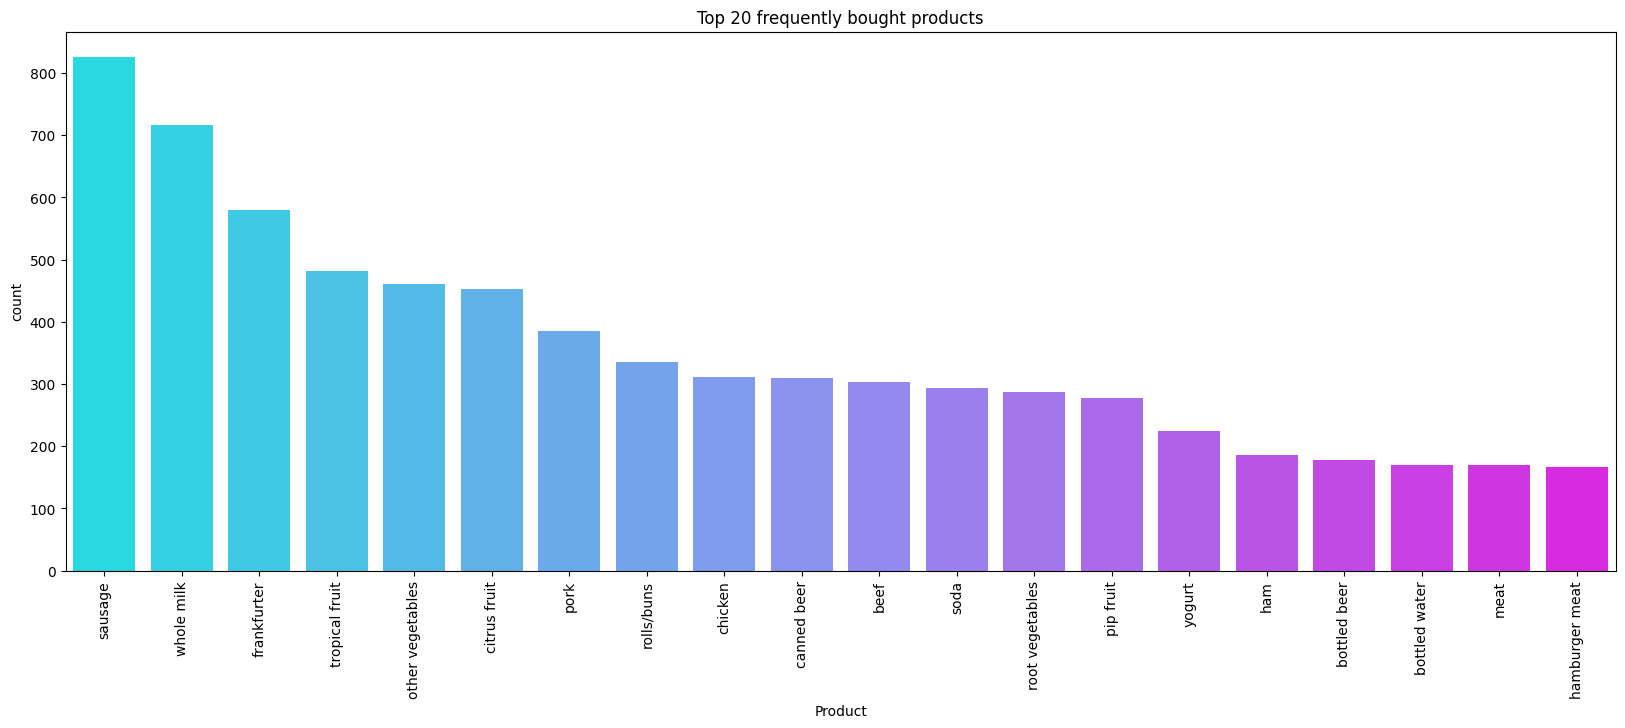

In [4]:
#Top 20 frequently buying items by customer
plt.rcParams['figure.figsize']=20,7
sns.countplot(data=data, x=data['Item 1'],
             order = data['Item 1'].value_counts().head(20).index,
             palette='cool')
plt.xticks(rotation=90)
plt.xlabel('Product')
plt.title('Top 20 frequently bought products')
plt.show()

In [5]:
#let's create a list of list of transaction
records = []
for i in range(0, len(data)):
    records.append([str(data.values[i,j]) for j in range(1, data.values[i, 0]+1)])

In [6]:
records

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['potted plants'],
 ['whole milk', 'cereals'],
 ['tropical fruit',
  'other vegetables',
  'white bread',
  'bottled water',
  'chocolate'],
 ['citrus fruit',
  'tropical fruit',
  'whole milk',
  'butter',
  'curd',
  'yogurt',
  'flour',
  'bottled water',
  'dishes'],
 ['beef'],
 ['frankfurter', 'rolls/buns', 'soda'],
 ['chicken', 'tropical fruit'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter mi

#Let's analyze the no. of items wrt each transaction
counts = [len(abc) for abc in records]
print(f'50 percent of the transactions are having items below or equal to {np.quantile(counts, .5)} only')
print(f'particular transaction having a maximum of {np.quantile(counts, 1)} items in it')

In [7]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
onehot = te.fit_transform(records)
onehot = pd.DataFrame(onehot, columns = te.columns_)

Using Transactionencoder we can transform this dataset into a logical data frame.
Each column represents an item and each row represent a record or a transaction for one purchase.

In [8]:
onehot.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [9]:
#Shape of encoded onehot dataset
print(f'No.of Transection data: {onehot.shape[0]} rows and {onehot.shape[1]} unique Product(Columns)')

No.of Transection data: 9835 rows and 169 unique Product(Columns)


In [10]:
from mlxtend.frequent_patterns import apriori, fpmax, fpgrowth

frequent_itemsets = apriori(onehot, min_support=0.001,use_colnames=True, max_len=3,verbose=1)

frequent_itemsets

Processing 411195 combinations | Sampling itemset size 3


,support,itemsets
0,0.008033,frozenset({Instant food products})
1,0.033452,frozenset({UHT-milk})
2,0.003559,frozenset({abrasive cleaner})
3,0.003254,frozenset({artif. sweetener})
4,0.017692,frozenset({baking powder})
...,...,...
9964,0.003559,"frozenset({waffles, yogurt, whole milk})"
9965,0.003050,"frozenset({whipped/sour cream, whole milk, whi..."
9966,0.002135,"frozenset({whipped/sour cream, yogurt, white b..."
9967,0.010880,"frozenset({yogurt, whipped/sour cream, whole m..."


In [11]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)  
rules = rules.sort_values('lift', ascending=False)

In [12]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
9816,frozenset({liquor}),"frozenset({red/blush wine, bottled beer})",0.011083,0.004881,0.001932,0.174312,35.715787,1.0,0.001878,1.205200,0.982894,0.137681,0.170262,0.285073
9813,"frozenset({red/blush wine, bottled beer})",frozenset({liquor}),0.004881,0.011083,0.001932,0.395833,35.715787,1.0,0.001878,1.636828,0.976768,0.137681,0.389062,0.285073
5434,"frozenset({hamburger meat, soda})",frozenset({Instant food products}),0.005796,0.008033,0.001220,0.210526,26.209194,1.0,0.001174,1.256492,0.967452,0.096774,0.204133,0.181213
5439,frozenset({Instant food products}),"frozenset({hamburger meat, soda})",0.008033,0.005796,0.001220,0.151899,26.209194,1.0,0.001174,1.172271,0.969634,0.096774,0.146955,0.181213
34594,"frozenset({ham, white bread})",frozenset({processed cheese}),0.005084,0.016573,0.001932,0.380000,22.928221,1.0,0.001848,1.586172,0.961273,0.097938,0.369551,0.248282


In [13]:
Output = round(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']],3)  # rounding off number by 2 digit after decimal 

Output.head(10)

,antecedents,consequents,support,confidence,lift
9816,frozenset({liquor}),"frozenset({red/blush wine, bottled beer})",0.002,0.174,35.716
9813,"frozenset({red/blush wine, bottled beer})",frozenset({liquor}),0.002,0.396,35.716
5434,"frozenset({hamburger meat, soda})",frozenset({Instant food products}),0.001,0.211,26.209
5439,frozenset({Instant food products}),"frozenset({hamburger meat, soda})",0.001,0.152,26.209
34594,"frozenset({ham, white bread})",frozenset({processed cheese}),0.002,0.380,22.928
34595,frozenset({processed cheese}),"frozenset({ham, white bread})",0.002,0.117,22.928
9815,frozenset({red/blush wine}),"frozenset({bottled beer, liquor})",0.002,0.101,21.494
9814,"frozenset({bottled beer, liquor})",frozenset({red/blush wine}),0.002,0.413,21.494
5436,"frozenset({soda, Instant food products})",frozenset({hamburger meat}),0.001,0.632,18.996
5437,frozenset({hamburger meat}),"frozenset({soda, Instant food products})",0.001,0.037,18.996


In [14]:
targeted_rules = Output[Output['consequents'] == {'Instant food products'}].copy()
targeted_rules

,antecedents,consequents,support,confidence,lift
5434,"frozenset({hamburger meat, soda})",frozenset({Instant food products}),0.001,0.211,26.209
5429,"frozenset({hamburger meat, rolls/buns})",frozenset({Instant food products}),0.001,0.118,14.646
5441,"frozenset({hamburger meat, whole milk})",frozenset({Instant food products}),0.002,0.103,12.879
12,frozenset({hamburger meat}),frozenset({Instant food products}),0.003,0.092,11.421
6,frozenset({curd}),frozenset({Instant food products}),0.001,0.025,3.089
3,frozenset({butter}),frozenset({Instant food products}),0.001,0.022,2.741
5447,"frozenset({root vegetables, other vegetables})",frozenset({Instant food products}),0.001,0.021,2.672
5454,"frozenset({other vegetables, whole milk})",frozenset({Instant food products}),0.002,0.020,2.537
5466,"frozenset({yogurt, whole milk})",frozenset({Instant food products}),0.001,0.020,2.485
5460,"frozenset({rolls/buns, whole milk})",frozenset({Instant food products}),0.001,0.020,2.459


In [15]:
targeted_rules = Output[Output['consequents'] == {'butter milk'}].copy()
targeted_rules

,antecedents,consequents,support,confidence,lift
17181,"frozenset({dessert, pip fruit})",frozenset({butter milk}),0.001,0.286,10.218
17115,"frozenset({pip fruit, cream cheese})",frozenset({butter milk}),0.001,0.167,5.961
17193,"frozenset({dessert, yogurt})",frozenset({butter milk}),0.002,0.165,5.899
17622,"frozenset({sliced cheese, yogurt})",frozenset({butter milk}),0.001,0.165,5.885
17187,"frozenset({dessert, whole milk})",frozenset({butter milk}),0.002,0.148,5.298
...,...,...,...,...,...
1143,frozenset({margarine}),frozenset({butter milk}),0.002,0.035,1.242
654,frozenset({bottled water}),frozenset({butter milk}),0.004,0.034,1.217
1104,frozenset({candy}),frozenset({butter milk}),0.001,0.034,1.216
17521,"frozenset({soda, rolls/buns})",frozenset({butter milk}),0.001,0.032,1.138


In [16]:
filtered_rules = targeted_rules[(targeted_rules['confidence'] > 0.1) &
                                (targeted_rules['lift'] > 1.00)]
filtered_rules

,antecedents,consequents,support,confidence,lift
17181,"frozenset({dessert, pip fruit})",frozenset({butter milk}),0.001,0.286,10.218
17115,"frozenset({pip fruit, cream cheese})",frozenset({butter milk}),0.001,0.167,5.961
17193,"frozenset({dessert, yogurt})",frozenset({butter milk}),0.002,0.165,5.899
17622,"frozenset({sliced cheese, yogurt})",frozenset({butter milk}),0.001,0.165,5.885
17187,"frozenset({dessert, whole milk})",frozenset({butter milk}),0.002,0.148,5.298
17122,"frozenset({rolls/buns, cream cheese})",frozenset({butter milk}),0.001,0.143,5.109
17145,"frozenset({pip fruit, curd})",frozenset({butter milk}),0.001,0.143,5.109
17247,"frozenset({pip fruit, frozen vegetables})",frozenset({butter milk}),0.001,0.139,4.967
17649,"frozenset({waffles, yogurt})",frozenset({butter milk}),0.001,0.135,4.833
17410,"frozenset({sliced cheese, other vegetables})",frozenset({butter milk}),0.001,0.135,4.822


# Finished

support_table = filtered_rules.pivot(index='consequents', columns='antecedents', values='lift')
support_table

sns.heatmap(support_table)

Output.to_csv("demo.csv")